In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv("../data/raw/complaints.csv")
df.head()

C:\Users\gebre\AppData\Local\Temp\ipykernel_3372\2649679485.py:1: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/complaints.csv")


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [3]:
df.shape

(9609797, 18)

In [4]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 1.3 GB


In [6]:
df["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

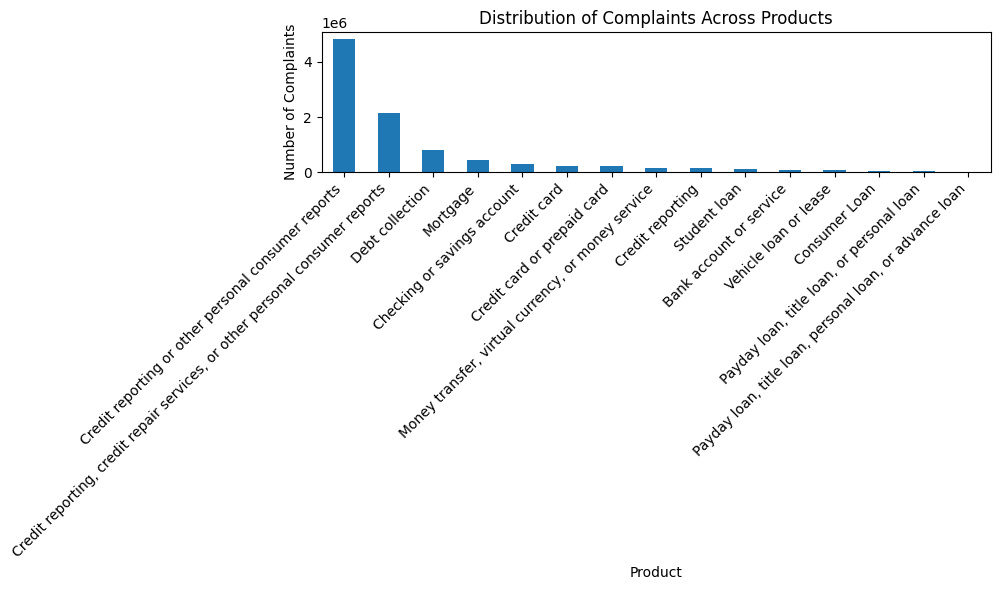

In [7]:
plt.figure(figsize=(10, 6))
df["Product"].value_counts().head(15).plot(kind="bar")
plt.title("Distribution of Complaints Across Products")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
narrative_col = "Consumer complaint narrative"

df["has_narrative"] = df[narrative_col].notna() & (df[narrative_col].astype(str).str.strip() != "")

df["has_narrative"].value_counts()

has_narrative
False    6629041
True     2980756
Name: count, dtype: int64

In [9]:
df["narrative_word_count"] = df[narrative_col].fillna("").astype(str).apply(lambda x: len(x.split()))

df["narrative_word_count"].describe()

count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: narrative_word_count, dtype: float64

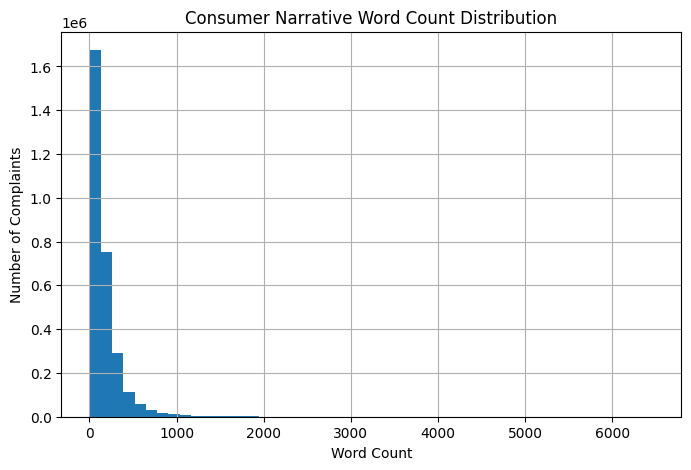

In [10]:
plt.figure(figsize=(8, 5))
df[df["has_narrative"]]["narrative_word_count"].hist(bins=50)
plt.title("Consumer Narrative Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Complaints")
plt.show()

In [11]:
target_products = [
    "Credit card",
    "Credit card or prepaid card",
    "Payday loan, title loan, or personal loan",
    "Personal loan",
    "Checking or savings account",
    "Money transfer, virtual currency, or money service"
]

filtered_df = df[df["Product"].isin(target_products)].copy()

filtered_df = filtered_df[
    filtered_df[narrative_col].notna() &
    (filtered_df[narrative_col].astype(str).str.strip() != "")
].copy()

filtered_df.shape

(444079, 20)

In [12]:
product_mapping = {
    "Credit card": "Credit Card",
    "Credit card or prepaid card": "Credit Card",
    "Payday loan, title loan, or personal loan": "Personal Loan",
    "Personal loan": "Personal Loan",
    "Checking or savings account": "Savings Account",
    "Money transfer, virtual currency, or money service": "Money Transfer"
}

filtered_df["product_category"] = filtered_df["Product"].map(product_mapping)

filtered_df["product_category"].value_counts()

product_category
Credit Card        189334
Savings Account    140319
Money Transfer      97188
Personal Loan       17238
Name: count, dtype: int64

In [13]:
def clean_text(text):
    text = str(text).lower()
    
    boilerplate_patterns = [
        r"i am writing to file a complaint",
        r"i am filing this complaint",
        r"this is a complaint",
        r"to whom it may concern"
    ]
    
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, " ", text)
    
    text = re.sub(r"x{2,}", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [14]:
filtered_df["clean_narrative"] = filtered_df[narrative_col].apply(clean_text)

filtered_df = filtered_df[filtered_df["clean_narrative"].str.len() > 0].copy()

filtered_df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,has_narrative,narrative_word_count,product_category,clean_narrative
12237,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,...,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,True,91,Credit Card,a card was opened under my name by a fraudster...
12532,2025-06-13,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,...,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897,True,109,Savings Account,i made the mistake of using my wellsfargo debi...
13280,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,...,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,True,156,Credit Card,dear cfpb i have a secured credit card with ci...
13506,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,...,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,True,233,Credit Card,i have a citi rewards cards the credit balance...
13955,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,...,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,True,454,Credit Card,b i am writing to dispute the following charge...


In [15]:
filtered_df["clean_word_count"] = filtered_df["clean_narrative"].apply(lambda x: len(x.split()))

filtered_df[["product_category", "clean_word_count"]].describe()

,clean_word_count
count,444075.000000
mean,195.657139
std,214.692272
min,1.000000
25%,79.000000
50%,130.000000
75%,243.000000
max,6239.000000


In [19]:
important_cols = [
    "Complaint ID",
    "Product",
    "product_category",
    "Issue",
    "Sub-issue",
    "Company",
    "State",
    "Date received",
    "Consumer complaint narrative",
    "clean_narrative",
    "clean_word_count"
]

available_cols = [col for col in important_cols if col in filtered_df.columns]

filtered_df[available_cols].to_csv(
    "../data/filtered_complaints.csv",
    index=False
)

print("Saved cleaned dataset to data/filtered_complaints.csv")
print(filtered_df[available_cols].shape)

Saved cleaned dataset to data/filtered_complaints.csv
(444075, 11)
